# Notebook 02 — Ingesta DAP y Fusión Dual

**Fase 1 · Módulos 1B + 1C** — Carga y normalización del dataset Dog Aging Project. Preparación del schema unificado para fusión con IDEXX.

**Entrada:** `externo/DAP_2023_SamplesResults_CBC_v1.0.csv`  
**Salida:** `data/interim/dap_parsed.csv`, `data/interim/dap_unified_ready.csv`, `data/interim/unified_raw_v2.csv`

| Sección | Contenido |
|---|---|
| **1** | Setup y dependencias |
| **2** | Carga y exploración del dataset DAP |
| **3** | Mapeo de columnas DAP → schema IDEXX |
| **4** | Campos morfológicos y clínicos |
| **5** | Filtrado de registros CBC completos |
| **6** | EDA: cobertura CBC y distribución de edad |
| **7** | Exportación del dataset DAP normalizado |
| **8** | Schema unificado y fusión IDEXX + DAP |
| **9** | Validación del dataset unificado (duplicados, campos, integridad) |
| **10** | Resumen de artefactos generados |


### Guia rapida del codigo

- Carga el CSV DAP, renombra columnas y filtra registros con CBC minimo.
- Prepara DAP e IDEXX con un esquema comun y `record_uuid`.
- Exporta `dap_parsed.csv`, `dap_unified_ready.csv`, `unified_raw.csv` y `unified_raw_v2.csv`.
- Las funciones principales son `generate_record_uuid`, `prepare_dap_for_unification` y `fuse_datasets`.


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Image
from pathlib import Path
from datetime import datetime
import hashlib
import json
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

PROJECT_ROOT = Path.cwd().parents[1]
DAP_CSV_PATH = PROJECT_ROOT / 'externo' / 'DAP_2023_SamplesResults_CBC_v1.0.csv'
INTERIM_DIR  = PROJECT_ROOT / 'data' / 'interim'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'

INTERIM_DIR.mkdir(parents=True, exist_ok=True)

OUTPUTS = PROJECT_ROOT / "outputs"
OUTPUTS.mkdir(parents=True, exist_ok=True)

def save_and_show(fig, filename, outputs_dir=OUTPUTS):
    """Guarda la figura, cierra el objeto y muestra inline."""
    path = outputs_dir / filename
    fig.savefig(path, dpi=150, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    display(Image(filename=str(path)))
    print(f"Guardado: {path}")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Proyecto raiz: {PROJECT_ROOT}")
print(f"CSV DAP: {DAP_CSV_PATH}")
print(f"Existe: {DAP_CSV_PATH.exists()}")

Proyecto raiz: /home/edwinb/tesis/hemogramas-proyectoICC
CSV DAP: /home/edwinb/tesis/hemogramas-proyectoICC/externo/DAP_2023_SamplesResults_CBC_v1.0.csv
Existe: True


## 2. Carga y exploracion

In [2]:
df_raw = pd.read_csv(DAP_CSV_PATH)

print(f"Filas: {len(df_raw):,}")
print(f"Columnas: {len(df_raw.columns)}")
print(f"Memoria: {df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nColumnas:")
for i, col in enumerate(df_raw.columns, 1):
    print(f"  {i:2d}. {col}")

Filas: 1,681
Columnas: 50
Memoria: 1.83 MB

Columnas:
   1. dog_id
   2. Sample_Year
   3. DAP_Sample_ID
   4. krt_cbc_total_wbcs
   5. krt_cbc_abs_metamyelocytes
   6. krt_cbc_abs_bands
   7. krt_cbc_abs_neutrophils
   8. krt_cbc_abs_lymphocytes
   9. krt_cbc_abs_monocytes
  10. krt_cbc_abs_eosinophils
  11. krt_cbc_abs_basophils
  12. krt_cbc_abs_other_cells
  13. krt_cbc_rel_metamyelocytes
  14. krt_cbc_rel_bands
  15. krt_cbc_rel_neutrophils
  16. krt_cbc_rel_lymphocytes
  17. krt_cbc_rel_monocytes
  18. krt_cbc_rel_eosinophils
  19. krt_cbc_rel_basophils
  20. krt_cbc_rel_other_cells
  21. krt_cbc_rbc
  22. krt_cbc_hgb
  23. krt_cbc_hct
  24. krt_cbc_pcv
  25. krt_cbc_mcv
  26. krt_cbc_mch
  27. krt_cbc_mchc
  28. krt_cbc_rdw
  29. krt_cbc_plt
  30. krt_cbc_mpv
  31. krt_cbc_pct
  32. krt_cbc_plt_quant
  33. krt_cbc_plt_morph
  34. krt_cbc_plt_morph_2
  35. krt_cbc_plt_morph_num
  36. krt_cbc_plt_morph_num_2
  37. krt_cbc_nucleated_rbcs
  38. krt_cbc_retic_per
  39. krt_cbc_retic_

In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1681 entries, 0 to 1680
Data columns (total 50 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   dog_id                      1681 non-null   int64  
 1   Sample_Year                 1681 non-null   str    
 2   DAP_Sample_ID               1681 non-null   str    
 3   krt_cbc_total_wbcs          1681 non-null   float64
 4   krt_cbc_abs_metamyelocytes  1675 non-null   float64
 5   krt_cbc_abs_bands           1675 non-null   float64
 6   krt_cbc_abs_neutrophils     1675 non-null   float64
 7   krt_cbc_abs_lymphocytes     1675 non-null   float64
 8   krt_cbc_abs_monocytes       1675 non-null   float64
 9   krt_cbc_abs_eosinophils     1675 non-null   float64
 10  krt_cbc_abs_basophils       1675 non-null   float64
 11  krt_cbc_abs_other_cells     1675 non-null   float64
 12  krt_cbc_rel_metamyelocytes  1675 non-null   float64
 13  krt_cbc_rel_bands           1675 non-null   

In [4]:
df_raw.head(3)

,dog_id,Sample_Year,DAP_Sample_ID,krt_cbc_total_wbcs,krt_cbc_abs_metamyelocytes,krt_cbc_abs_bands,krt_cbc_abs_neutrophils,krt_cbc_abs_lymphocytes,krt_cbc_abs_monocytes,krt_cbc_abs_eosinophils,...,krt_cbc_rbc_morph_2,krt_cbc_rbc_morph_3,krt_cbc_rbc_morph_num,krt_cbc_rbc_morph_num_2,krt_cbc_rbc_morph_num_3,krt_cbc_wbc_morph,krt_cbc_wbc_morph_2,krt_cbc_wbc_morph_num,krt_cbc_hemoparasites,krt_cbc_test_comments
0,43,precision_1,43-precision_1-CBC,8.78,0.0,0.0,6.67,1.14,0.97,0.00,...,NaN,NaN,1+,NaN,NaN,Reactive Lymphocytes,NaN,Rare,None Observed,NaN
1,43,precision_3,43-precision_3-CBC,7.64,0.0,0.0,5.65,0.99,0.61,0.38,...,NaN,NaN,2+,NaN,NaN,Unremarkable,NaN,NaN,None Observed,There is a reticulocytosis without an apparent...
2,154,precision_1,154-precision_1-CBC,4.75,0.0,0.0,3.42,1.09,0.19,0.05,...,NaN,NaN,1+,NaN,NaN,Unremarkable,NaN,NaN,None Observed,NaN


In [5]:
df_raw.describe().round(2)

,dog_id,krt_cbc_total_wbcs,krt_cbc_abs_metamyelocytes,krt_cbc_abs_bands,krt_cbc_abs_neutrophils,krt_cbc_abs_lymphocytes,krt_cbc_abs_monocytes,krt_cbc_abs_eosinophils,krt_cbc_abs_basophils,krt_cbc_abs_other_cells,...,krt_cbc_mcv,krt_cbc_mch,krt_cbc_mchc,krt_cbc_rdw,krt_cbc_plt,krt_cbc_mpv,krt_cbc_pct,krt_cbc_nucleated_rbcs,krt_cbc_retic_per,krt_cbc_retic_abs
count,1681.00,1681.00,1675.0,1675.00,1675.00,1675.00,1675.00,1675.00,1675.00,1675.0,...,1681.00,1681.00,1681.00,1681.00,1301.00,1678.00,1678.00,182.00,1678.00,1678.00
mean,65803.70,7.72,0.0,0.00,5.16,1.72,0.37,0.47,0.00,0.0,...,73.80,24.66,33.43,12.19,286.79,12.81,0.34,1.98,0.91,62.96
std,36308.73,2.35,0.0,0.02,1.93,0.82,0.25,0.50,0.02,0.0,...,3.45,1.17,1.02,0.72,101.92,3.93,0.12,5.58,1.44,33.91
min,43.00,2.85,0.0,0.00,0.00,0.08,0.00,0.00,0.00,0.0,...,58.20,19.30,27.70,10.50,20.00,6.50,0.03,1.00,0.12,0.80
25%,36088.00,6.16,0.0,0.00,3.86,1.15,0.20,0.22,0.00,0.0,...,71.60,23.90,32.80,11.80,222.00,10.00,0.26,1.00,0.53,37.12
50%,69239.00,7.39,0.0,0.00,4.85,1.58,0.33,0.38,0.00,0.0,...,73.80,24.70,33.50,12.10,269.00,12.10,0.33,1.00,0.80,57.80
75%,96243.00,8.86,0.0,0.00,6.06,2.15,0.48,0.60,0.00,0.0,...,75.90,25.40,34.10,12.50,330.00,14.80,0.41,1.00,1.15,83.45
max,136203.00,25.45,0.0,0.65,19.34,8.07,2.03,14.25,0.42,0.0,...,87.80,29.50,41.00,18.90,1026.00,38.30,1.06,60.00,56.60,372.00


In [6]:
print(f"Perros unicos (dog_id): {df_raw['dog_id'].nunique():,}")
print(f"Años de muestra: {sorted(df_raw['Sample_Year'].unique())}")
print(f"Muestras unicas: {df_raw['DAP_Sample_ID'].nunique():,}")
print(f"\nMuestras por perro:")
print(df_raw.groupby('dog_id').size().describe().round(1))

Perros unicos (dog_id): 1,044
Años de muestra: ['precision_1', 'precision_2', 'precision_3']
Muestras unicas: 1,681

Muestras por perro:
count    1044.0
mean        1.6
std         0.6
min         1.0
25%         1.0
50%         2.0
75%         2.0
max         3.0
dtype: float64


## 3. Mapeo de columnas

Las columnas DAP usan prefijo `krt_cbc_*`. Se renombran al schema estandar del proyecto.

In [7]:
DAP_COLUMN_MAP = {
    # Identificadores
    'dog_id':       'original_id',
    'Sample_Year':  'sample_year',
    'DAP_Sample_ID': 'sample_id',
    
    # Serie Blanca
    'krt_cbc_total_wbcs':       'WBC',
    'krt_cbc_abs_neutrophils':  'Neutrophils',
    'krt_cbc_rel_neutrophils':  'Neutrophils_pct',
    'krt_cbc_abs_lymphocytes':  'Lymphocytes',
    'krt_cbc_rel_lymphocytes':  'Lymphocytes_pct',
    'krt_cbc_abs_monocytes':    'Monocytes',
    'krt_cbc_rel_monocytes':    'Monocytes_pct',
    'krt_cbc_abs_eosinophils':  'Eosinophils',
    'krt_cbc_rel_eosinophils':  'Eosinophils_pct',
    'krt_cbc_abs_basophils':    'Basophils',
    'krt_cbc_rel_basophils':    'Basophils_pct',
    'krt_cbc_abs_bands':        'Bands',
    'krt_cbc_rel_bands':        'Bands_pct',
    'krt_cbc_abs_metamyelocytes': 'Metamyelocytes',
    'krt_cbc_rel_metamyelocytes': 'Metamyelocytes_pct',
    'krt_cbc_abs_other_cells':  'Other_cells',
    'krt_cbc_rel_other_cells':  'Other_cells_pct',
    
    # Serie Roja
    'krt_cbc_rbc':   'RBC',
    'krt_cbc_hgb':   'HGB',
    'krt_cbc_hct':   'HCT',
    'krt_cbc_pcv':   'PCV',
    'krt_cbc_mcv':   'MCV',
    'krt_cbc_mch':   'MCH',
    'krt_cbc_mchc':  'MCHC',
    'krt_cbc_rdw':   'RDW',
    
    # Plaquetas
    'krt_cbc_plt':   'Platelets',
    'krt_cbc_mpv':   'MPV',
    'krt_cbc_pct':   'PCT',
    
    # Reticulocitos
    'krt_cbc_retic_per': 'Reticulocytes_pct',
    'krt_cbc_retic_abs': 'Reticulocytes',
    'krt_cbc_nucleated_rbcs': 'nRBC',
    
    # Morfologia y Comentarios
    'krt_cbc_plt_quant':      'plt_quantification',
    'krt_cbc_plt_morph':      'plt_morphology_1',
    'krt_cbc_plt_morph_2':    'plt_morphology_2',
    'krt_cbc_plt_morph_num':  'plt_morph_severity_1',
    'krt_cbc_plt_morph_num_2':'plt_morph_severity_2',
    'krt_cbc_rbc_morph':      'rbc_morphology_1',
    'krt_cbc_rbc_morph_2':    'rbc_morphology_2',
    'krt_cbc_rbc_morph_3':    'rbc_morphology_3',
    'krt_cbc_rbc_morph_num':  'rbc_morph_severity_1',
    'krt_cbc_rbc_morph_num_2':'rbc_morph_severity_2',
    'krt_cbc_rbc_morph_num_3':'rbc_morph_severity_3',
    'krt_cbc_wbc_morph':      'wbc_morphology_1',
    'krt_cbc_wbc_morph_2':    'wbc_morphology_2',
    'krt_cbc_wbc_morph_num':  'wbc_morph_severity',
    'krt_cbc_hemoparasites':  'hemoparasites',
    'krt_cbc_test_comments':  'test_comments',
}

unmapped = set(df_raw.columns) - set(DAP_COLUMN_MAP.keys())
if unmapped:
    print(f"Columnas sin mapear: {unmapped}")
else:
    print(f"Todas las {len(DAP_COLUMN_MAP)} columnas mapeadas")

Todas las 50 columnas mapeadas


In [8]:
df = df_raw.rename(columns=DAP_COLUMN_MAP).copy()
df['source_dataset'] = 'DAP'
df['ingestion_timestamp'] = datetime.now().isoformat()

print(f"Columnas renombradas: {len(df.columns)}")
print(df.columns.tolist())

Columnas renombradas: 52
['original_id', 'sample_year', 'sample_id', 'WBC', 'Metamyelocytes', 'Bands', 'Neutrophils', 'Lymphocytes', 'Monocytes', 'Eosinophils', 'Basophils', 'Other_cells', 'Metamyelocytes_pct', 'Bands_pct', 'Neutrophils_pct', 'Lymphocytes_pct', 'Monocytes_pct', 'Eosinophils_pct', 'Basophils_pct', 'Other_cells_pct', 'RBC', 'HGB', 'HCT', 'PCV', 'MCV', 'MCH', 'MCHC', 'RDW', 'Platelets', 'MPV', 'PCT', 'plt_quantification', 'plt_morphology_1', 'plt_morphology_2', 'plt_morph_severity_1', 'plt_morph_severity_2', 'nRBC', 'Reticulocytes_pct', 'Reticulocytes', 'rbc_morphology_1', 'rbc_morphology_2', 'rbc_morphology_3', 'rbc_morph_severity_1', 'rbc_morph_severity_2', 'rbc_morph_severity_3', 'wbc_morphology_1', 'wbc_morphology_2', 'wbc_morph_severity', 'hemoparasites', 'test_comments', 'source_dataset', 'ingestion_timestamp']


## 4. Campos morfologicos y clinicos

In [9]:
morph_cols = [
    'plt_quantification', 'plt_morphology_1', 'plt_morph_severity_1',
    'rbc_morphology_1', 'rbc_morph_severity_1',
    'wbc_morphology_1', 'wbc_morph_severity',
    'hemoparasites', 'test_comments'
]

print("VALORES UNICOS EN CAMPOS MORFOLOGICOS\n")
for col in morph_cols:
    if col in df.columns:
        non_null = df[col].notna().sum()
        unique_vals = df[col].dropna().unique()
        print(f"--- {col} ({non_null}/{len(df)} no-nulos, {len(unique_vals)} unicos) ---")
        for v in sorted(unique_vals)[:10]:
            count = (df[col] == v).sum()
            print(f"  {v}: {count}")
        if len(unique_vals) > 10:
            print(f"  ... y {len(unique_vals) - 10} mas")
        print()

VALORES UNICOS EN CAMPOS MORFOLOGICOS

--- plt_quantification (1656/1681 no-nulos, 3 unicos) ---
  Appear Adequate: 1571
  Appear Decreased: 26
  Appear Increased: 59

--- plt_morphology_1 (876/1681 no-nulos, 2 unicos) ---
  Clumped: 854
  Enlarged: 22

--- plt_morph_severity_1 (875/1681 no-nulos, 7 unicos) ---
  1+: 16
  2+: 3
  3+: 2
  4+: 1
  Marked: 339
  Mild: 382
  Moderate: 132

--- rbc_morphology_1 (1669/1681 no-nulos, 7 unicos) ---
  Anisocytosis: 1
  Crenation: 1474
  Howell Jolly Bodies: 1
  Lipemia Artifacts Observed: 15
  Polychromasia: 80
  See Comments: 18
  Unremarkable: 80

--- rbc_morph_severity_1 (1554/1681 no-nulos, 5 unicos) ---
  1+: 184
  2+: 201
  3+: 164
  4+: 1004
  Mild: 1

--- wbc_morphology_1 (1676/1681 no-nulos, 5 unicos) ---
  Dohle Bodies: 104
  Reactive Lymphocytes: 77
  See Comments: 87
  Toxic Neutrophils: 1
  Unremarkable: 1407

--- wbc_morph_severity (182/1681 no-nulos, 5 unicos) ---
  1+: 130
  2+: 17
  3+: 2
  4+: 2
  Rare: 31

--- hemoparasites (

Hemoparasitos:
hemoparasites
None Observed    1680
NaN                 1
Name: count, dtype: int64


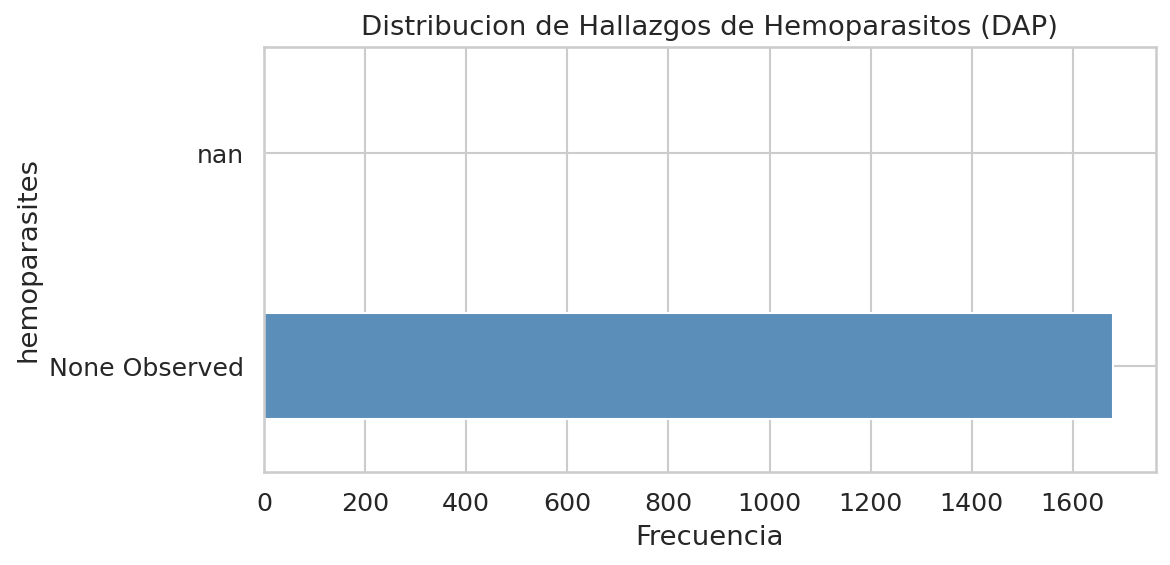

Guardado: /home/edwinb/tesis/hemogramas-proyectoICC/outputs/nb02_hemoparasitos.png


In [10]:
# Hemoparasitos
if 'hemoparasites' in df.columns:
    hemo_counts = df['hemoparasites'].value_counts(dropna=False)
    print("Hemoparasitos:")
    print(hemo_counts)
    
    fig, ax = plt.subplots(figsize=(8, 4))
    hemo_counts.dropna().plot(kind='barh', ax=ax, color='#5B8FB9')
    ax.set_title('Distribucion de Hallazgos de Hemoparasitos (DAP)')
    ax.set_xlabel('Frecuencia')
    plt.tight_layout()
    save_and_show(fig, "nb02_hemoparasitos.png")

In [11]:
# Morfologia plaquetaria
print("Morfologia plaquetaria:\n")
for col in ['plt_quantification', 'plt_morphology_1', 'plt_morph_severity_1']:
    if col in df.columns:
        print(f"{col}:")
        print(df[col].value_counts(dropna=False).head(10))
        print()

Morfologia plaquetaria:

plt_quantification:
plt_quantification
Appear Adequate     1571
Appear Increased      59
Appear Decreased      26
NaN                   25
Name: count, dtype: int64

plt_morphology_1:
plt_morphology_1
Clumped     854
NaN         805
Enlarged     22
Name: count, dtype: int64

plt_morph_severity_1:
plt_morph_severity_1
NaN         806
Mild        382
Marked      339
Moderate    132
1+           16
2+            3
3+            2
4+            1
Name: count, dtype: int64



In [12]:
# Comentarios clinicos (muestreo)
comments = df['test_comments'].dropna()
print(f"Registros con comentarios: {len(comments)} / {len(df)} ({len(comments)/len(df)*100:.1f}%)\n")

if len(comments) > 0:
    for i, comment in enumerate(comments.sample(min(5, len(comments)), random_state=42)):
        print(f"--- Ejemplo {i+1} ---")
        print(comment[:300])
        print()

Registros con comentarios: 441 / 1681 (26.2%)

--- Ejemplo 1 ---
Per EJ, no poly. 

--- Ejemplo 2 ---
Platelet clumps are present on the smear and can falsely decrease both the automated and estimated platelet counts. The platelet count given should be considered a minimum.

--- Ejemplo 3 ---
plt count verified manually

--- Ejemplo 4 ---
Platelets were clumped on blood smear, but numbers appear to be at least adequate.

--- Ejemplo 5 ---
Platelet clumps are present on the smear and can falsely decrease both the automated and estimated platelet counts. The platelet count given should be considered a minimum. A new sample is required for an accurate platelet count.Hemolysis is present in this sample. Hemolysis can affect automated par



## 5. Filtrado de registros CBC

Un registro valido requiere al menos RBC, WBC y Platelets presentes.

In [13]:
CRITICAL_CBC = ['RBC', 'WBC', 'Platelets']

print("Completitud pre-filtrado:\n")
for field in CRITICAL_CBC:
    present = df[field].notna().sum()
    pct = present / len(df) * 100
    print(f"  {field:>10s}: {present:,} / {len(df):,} ({pct:.1f}%)")

all_present = df[CRITICAL_CBC].notna().all(axis=1).sum()
print(f"\n  {'TODOS':>10s}: {all_present:,} / {len(df):,} ({all_present/len(df)*100:.1f}%)")

Completitud pre-filtrado:

         RBC: 1,681 / 1,681 (100.0%)
         WBC: 1,681 / 1,681 (100.0%)
   Platelets: 1,301 / 1,681 (77.4%)

       TODOS: 1,301 / 1,681 (77.4%)


In [14]:
df_cbc = df.dropna(subset=CRITICAL_CBC, how='any').copy()

removed = len(df) - len(df_cbc)
print(f"Filtrado CBC:")
print(f"  Antes: {len(df):,}")
print(f"  Despues: {len(df_cbc):,}")
print(f"  Removidos: {removed:,} ({removed/len(df)*100:.1f}%)")

Filtrado CBC:
  Antes: 1,681
  Despues: 1,301
  Removidos: 380 (22.6%)


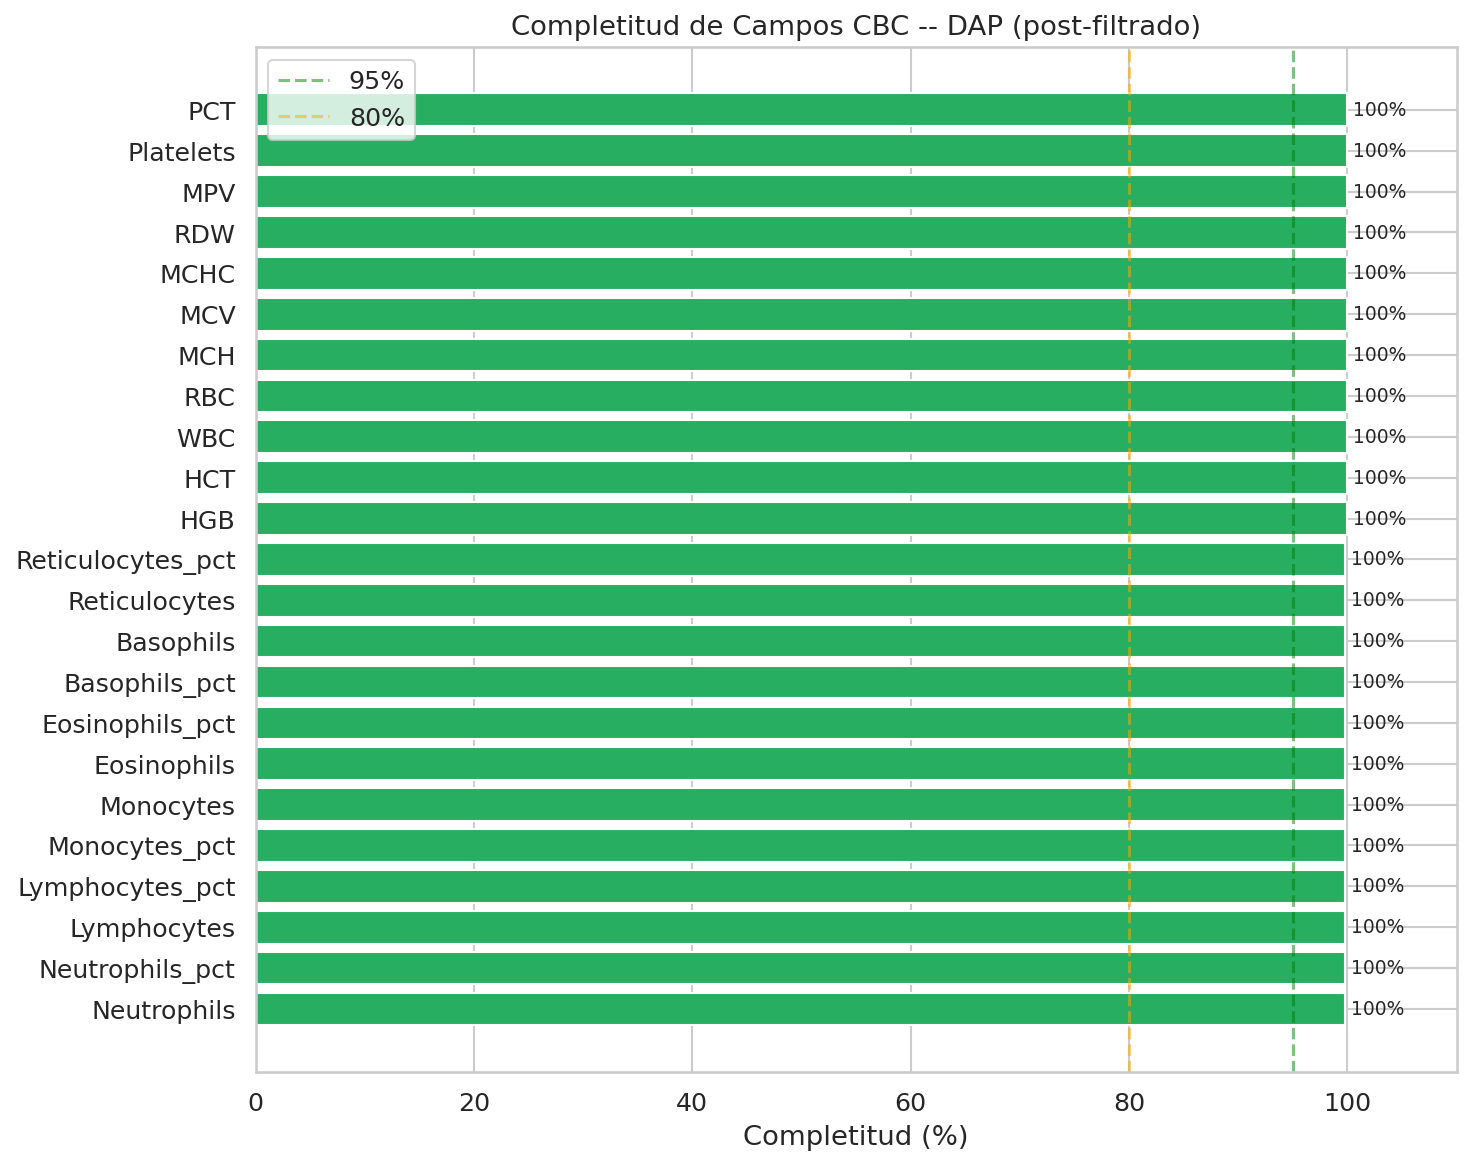

Guardado: /home/edwinb/tesis/hemogramas-proyectoICC/outputs/nb02_completitud_cbc_dap.png
Integridad promedio: 99.9%


In [15]:
# Completitud de todos los campos numericos CBC
numeric_cbc_cols = [
    'WBC', 'Neutrophils', 'Neutrophils_pct', 'Lymphocytes', 'Lymphocytes_pct',
    'Monocytes', 'Monocytes_pct', 'Eosinophils', 'Eosinophils_pct',
    'Basophils', 'Basophils_pct',
    'RBC', 'HGB', 'HCT', 'MCV', 'MCH', 'MCHC', 'RDW',
    'Platelets', 'MPV', 'PCT',
    'Reticulocytes', 'Reticulocytes_pct'
]

completeness = pd.DataFrame({
    'campo': numeric_cbc_cols,
    'presentes': [df_cbc[c].notna().sum() if c in df_cbc.columns else 0 for c in numeric_cbc_cols],
    'total': len(df_cbc)
})
completeness['pct'] = (completeness['presentes'] / completeness['total'] * 100).round(1)
completeness = completeness.sort_values('pct', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#E74C3C' if p < 80 else '#F39C12' if p < 95 else '#27AE60' for p in completeness['pct']]
bars = ax.barh(completeness['campo'], completeness['pct'], color=colors)
ax.set_xlabel('Completitud (%)')
ax.set_title('Completitud de Campos CBC -- DAP (post-filtrado)')
ax.axvline(x=95, color='green', linestyle='--', alpha=0.5, label='95%')
ax.axvline(x=80, color='orange', linestyle='--', alpha=0.5, label='80%')
for bar, pct in zip(bars, completeness['pct']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
            f'{pct:.0f}%', va='center', fontsize=9)
ax.legend()
ax.set_xlim(0, 110)
plt.tight_layout()
save_and_show(fig, "nb02_completitud_cbc_dap.png")

print(f"Integridad promedio: {completeness['pct'].mean():.1f}%")

## 6. EDA de variables CBC

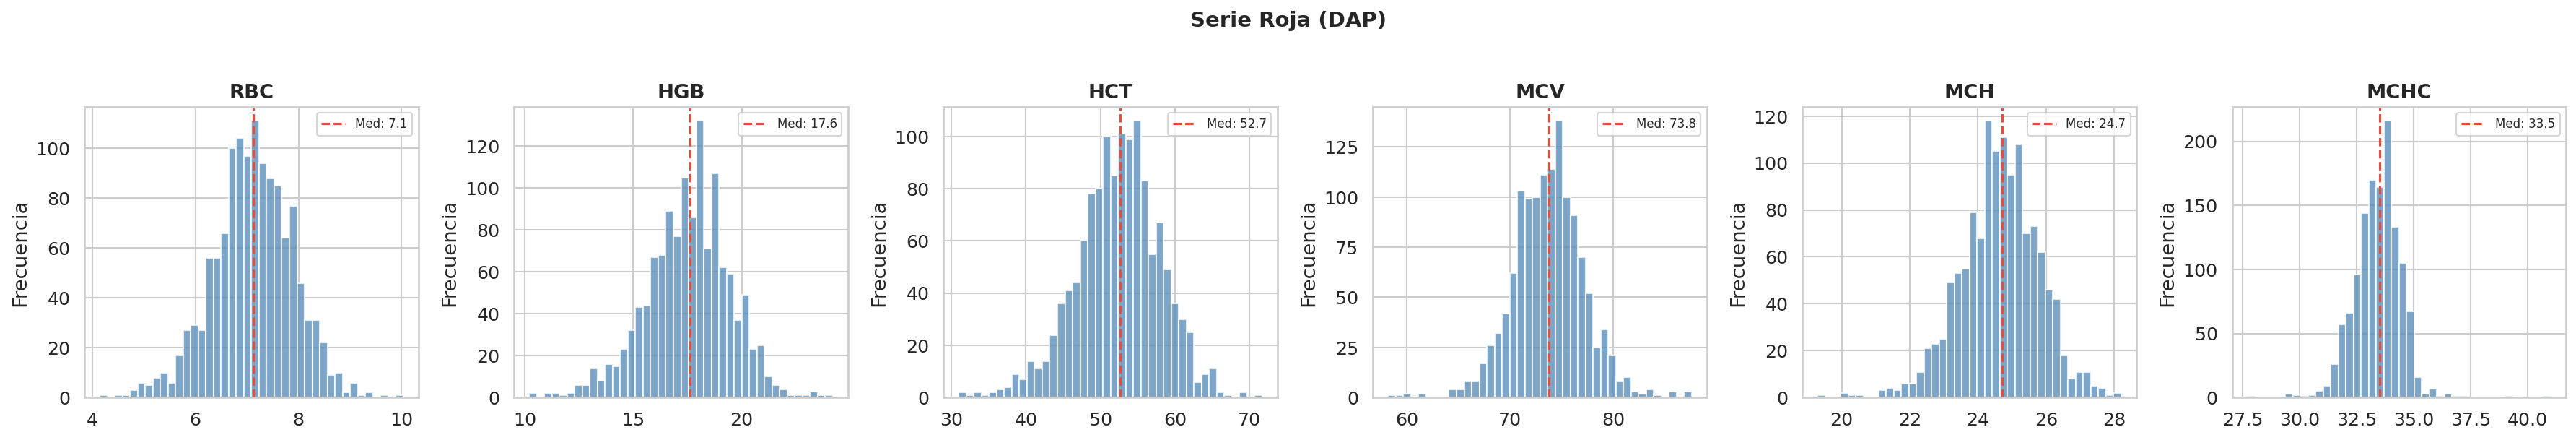

Guardado: /home/edwinb/tesis/hemogramas-proyectoICC/outputs/nb02_eda_serie_roja.png


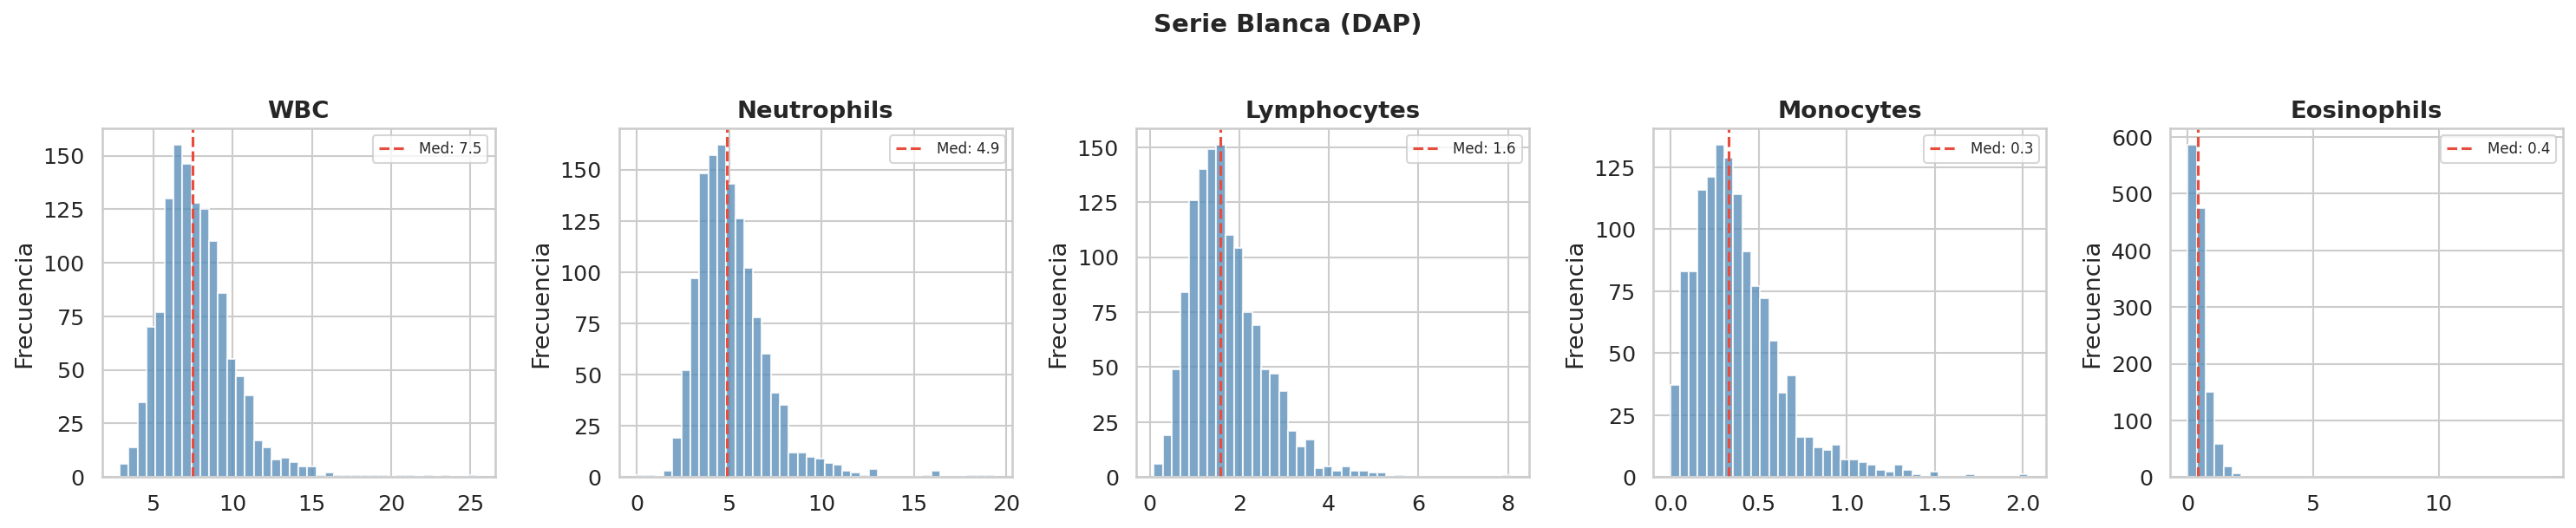

Guardado: /home/edwinb/tesis/hemogramas-proyectoICC/outputs/nb02_eda_serie_blanca.png


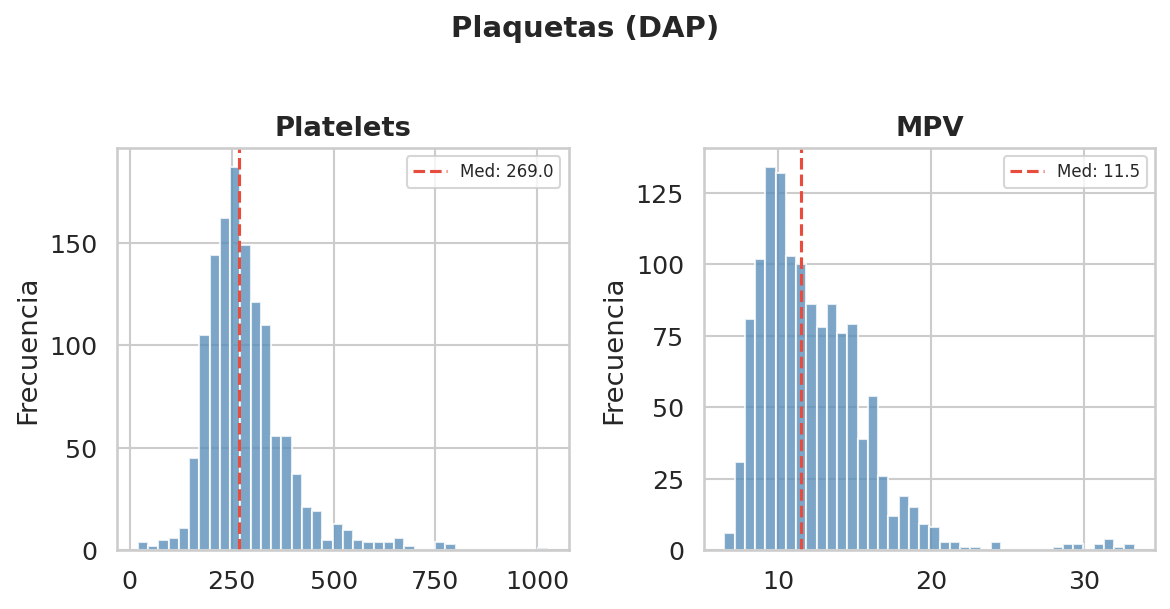

Guardado: /home/edwinb/tesis/hemogramas-proyectoICC/outputs/nb02_eda_plaquetas.png


In [16]:
eda_params = {
    'Serie Roja': ['RBC', 'HGB', 'HCT', 'MCV', 'MCH', 'MCHC'],
    'Serie Blanca': ['WBC', 'Neutrophils', 'Lymphocytes', 'Monocytes', 'Eosinophils'],
    'Plaquetas': ['Platelets', 'MPV']
}

_serie_counter = 0
for serie_name, params in eda_params.items():
    available = [p for p in params if p in df_cbc.columns and df_cbc[p].notna().sum() > 10]
    if not available:
        continue
    
    n = len(available)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1:
        axes = [axes]
    fig.suptitle(f'{serie_name} (DAP)', fontsize=14, fontweight='bold', y=1.02)
    
    for ax, param in zip(axes, available):
        data = df_cbc[param].dropna()
        ax.hist(data, bins=40, color='#5B8FB9', edgecolor='white', alpha=0.8)
        ax.axvline(data.median(), color='#E74C3C', linestyle='--', linewidth=1.5,
                   label=f'Med: {data.median():.1f}')
        ax.set_title(param, fontweight='bold')
        ax.set_ylabel('Frecuencia')
        ax.legend(fontsize=8)
    plt.tight_layout()
    _fname = f"nb02_eda_{serie_name.lower().replace(' ', '_')}.png"
    save_and_show(fig, _fname)
    _serie_counter += 1

In [17]:
# Resumen estadistico
all_cbc = [p for group in eda_params.values() for p in group if p in df_cbc.columns]
summary = df_cbc[all_cbc].describe().T
summary['CV%'] = (summary['std'] / summary['mean'] * 100).round(1)
summary = summary[['count', 'mean', 'std', 'CV%', 'min', '25%', '50%', '75%', 'max']].round(2)
print("Resumen estadistico CBC (DAP)\n")
print(summary.to_string())

Resumen estadistico CBC (DAP)

              count    mean     std    CV%    min     25%     50%     75%      max
RBC          1301.0    7.12    0.78   10.9   4.15    6.65    7.12    7.63    10.03
HGB          1301.0   17.52    1.92   11.0  10.20   16.30   17.60   18.80    24.20
HCT          1301.0   52.43    5.61   10.7  31.00   49.00   52.70   56.00    71.70
MCV          1301.0   73.74    3.42    4.6  58.20   71.60   73.80   75.90    87.60
MCH          1301.0   24.64    1.15    4.7  19.30   23.90   24.70   25.40    28.20
MCHC         1301.0   33.43    1.01    3.0  27.70   32.80   33.50   34.10    41.00
WBC          1301.0    7.79    2.41   31.0   2.85    6.19    7.45    8.95    25.45
Neutrophils  1298.0    5.20    1.98   38.1   0.00    3.87    4.86    6.12    19.34
Lymphocytes  1298.0    1.74    0.84   48.2   0.09    1.15    1.58    2.18     8.07
Monocytes    1298.0    0.38    0.25   65.9   0.00    0.21    0.33    0.50     2.03
Eosinophils  1298.0    0.48    0.52  109.6   0.00    0.2

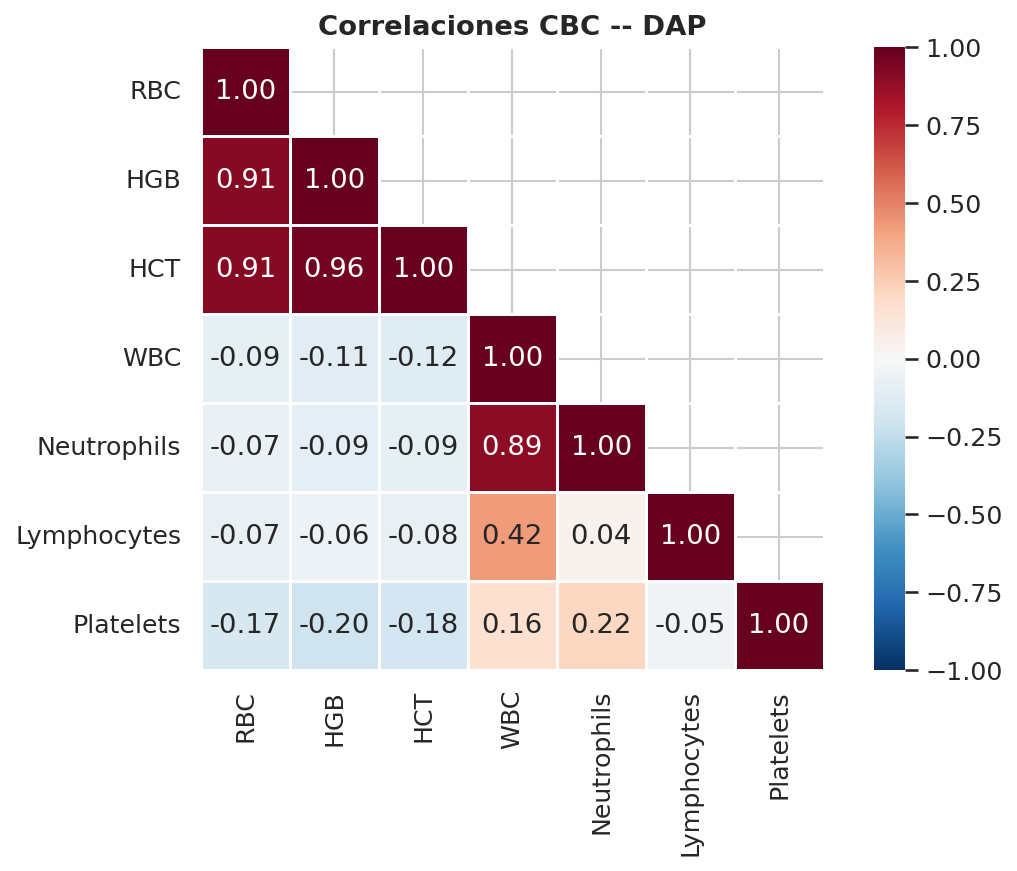

Guardado: /home/edwinb/tesis/hemogramas-proyectoICC/outputs/nb02_correlaciones_cbc_dap.png


In [18]:
# Matriz de correlacion
corr_params = ['RBC', 'HGB', 'HCT', 'WBC', 'Neutrophils', 'Lymphocytes', 'Platelets']
corr_available = [p for p in corr_params if p in df_cbc.columns]
corr_matrix = df_cbc[corr_available].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True, linewidths=0.5)
ax.set_title('Correlaciones CBC -- DAP', fontweight='bold')
plt.tight_layout()
save_and_show(fig, "nb02_correlaciones_cbc_dap.png")

### 6.1 Comparacion de fuentes: cobertura CBC

Barras agrupadas mostrando la completitud de cada variable CBC
en IDEXX vs DAP. Permite identificar variables exclusivas de una fuente.

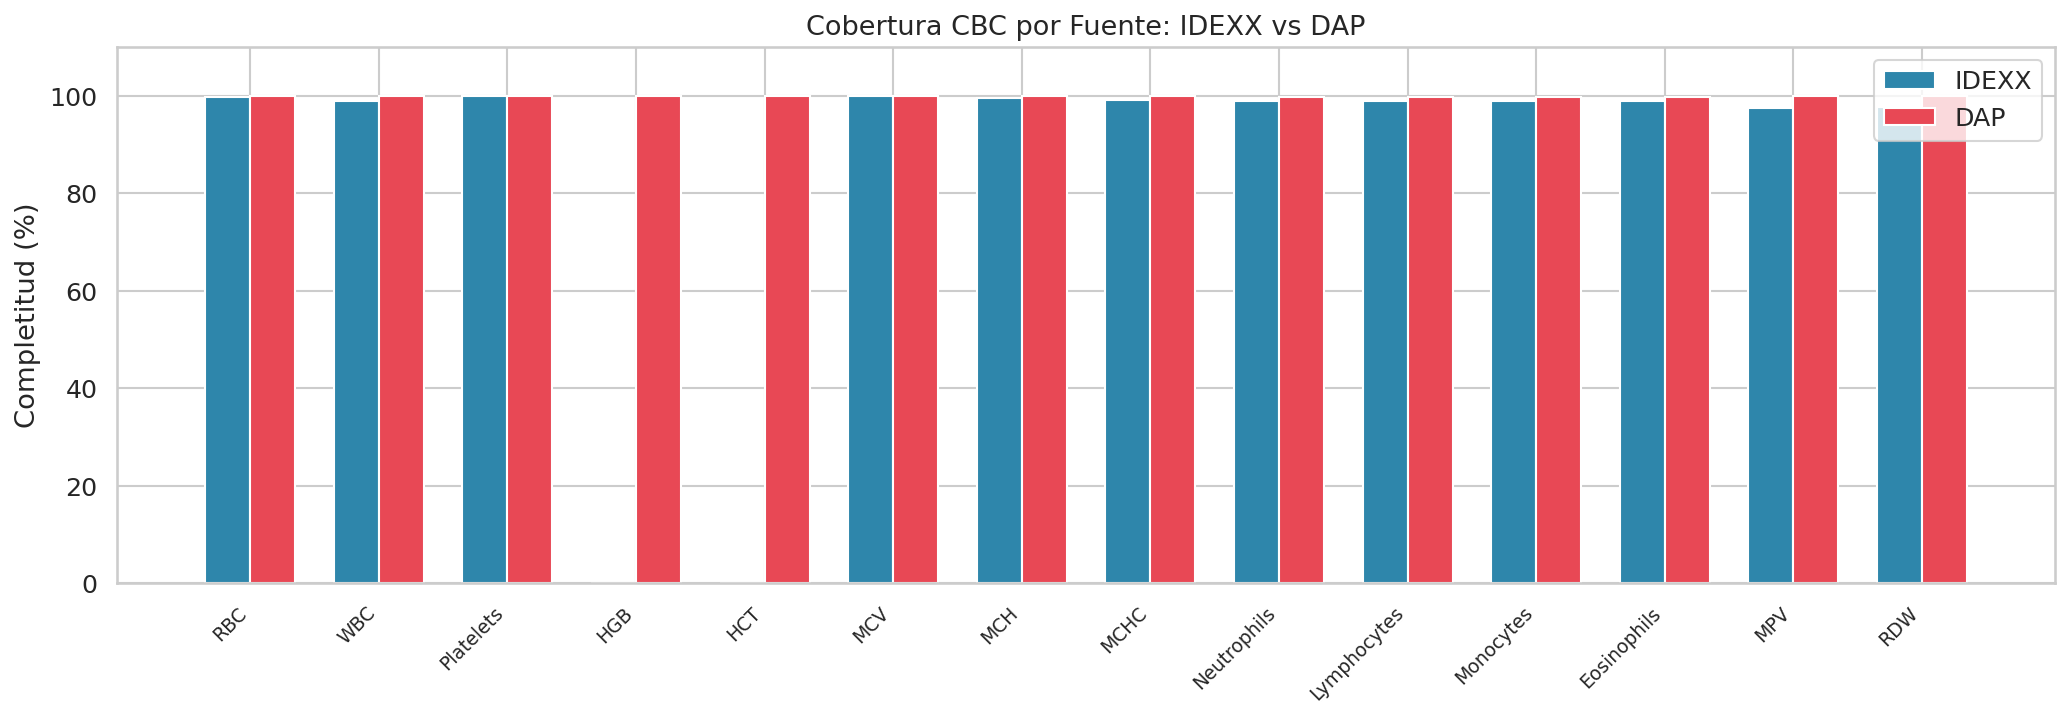

Guardado: /home/edwinb/tesis/hemogramas-proyectoICC/outputs/nb02_comparacion_fuentes.png


In [19]:
# Comparacion de cobertura CBC por fuente
# Cargar IDEXX para comparacion
idexx_path = INTERIM_DIR / "idexx_extracted.csv"
if idexx_path.exists():
    df_idexx_comp = pd.read_csv(idexx_path)
    cbc_compare = [
        "RBC", "WBC", "Platelets", "HGB", "HCT", "MCV", "MCH", "MCHC",
        "Neutrophils", "Lymphocytes", "Monocytes", "Eosinophils",
        "MPV", "RDW",
    ]
    cbc_avail = [c for c in cbc_compare if c in df_cbc.columns or c in df_idexx_comp.columns]

    idexx_pct = [df_idexx_comp[c].notna().mean() * 100 if c in df_idexx_comp.columns else 0
                 for c in cbc_avail]
    dap_pct = [df_cbc[c].notna().mean() * 100 if c in df_cbc.columns else 0
               for c in cbc_avail]

    import numpy as np
    x = np.arange(len(cbc_avail))
    width = 0.35

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(x - width/2, idexx_pct, width, label="IDEXX", color="#2E86AB")
    ax.bar(x + width/2, dap_pct, width, label="DAP", color="#E84855")
    ax.set_xticks(x)
    ax.set_xticklabels(cbc_avail, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Completitud (%)")
    ax.set_title("Cobertura CBC por Fuente: IDEXX vs DAP", fontsize=13)
    ax.legend()
    ax.set_ylim(0, 110)
    plt.tight_layout()
    save_and_show(fig, "nb02_comparacion_fuentes.png")
else:
    print("idexx_extracted.csv no encontrado; omitiendo comparacion.")


### 6.2 Distribucion de edad (DAP)

Histograma de la edad de los perros en el dataset DAP, dato relevante
para la estratificacion demografica.

In [20]:
# Distribucion de edad en DAP
age_col = None
for candidate in ["age_years", "age", "ageAtSample"]:
    if candidate in df_cbc.columns:
        age_col = candidate
        break

if age_col is not None:
    age_vals = pd.to_numeric(df_cbc[age_col], errors="coerce").dropna()
    if len(age_vals) > 10:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.hist(age_vals, bins=30, color="#2E86AB", edgecolor="white", alpha=0.8)
        ax.axvline(age_vals.median(), color="#E74C3C", linestyle="--",
                   linewidth=1.5, label=f"Mediana: {age_vals.median():.1f}")
        ax.set_xlabel("Edad (anos)")
        ax.set_ylabel("Frecuencia")
        ax.set_title("Distribucion de Edad -- DAP", fontsize=13)
        ax.legend()
        plt.tight_layout()
        save_and_show(fig, "nb02_distribucion_edad_dap.png")
    else:
        print(f"Insuficientes valores de edad ({len(age_vals)}).")
else:
    print("Columna de edad no encontrada en DAP.")


Columna de edad no encontrada en DAP.


## 7. Export

In [21]:
# Visualizar antes de guardar
print(f"Shape: {df_cbc.shape}")
print(f"\nPrimeras filas:")
print(df_cbc.head())


Shape: (1301, 52)

Primeras filas:
   original_id  sample_year            sample_id   WBC  Metamyelocytes  Bands  \
0           43  precision_1   43-precision_1-CBC  8.78             0.0    0.0   
1           43  precision_3   43-precision_3-CBC  7.64             0.0    0.0   
2          154  precision_1  154-precision_1-CBC  4.75             0.0    0.0   
3          154  precision_2  154-precision_2-CBC  6.38             0.0    0.0   
5          225  precision_2  225-precision_2-CBC  7.58             0.0    0.0   

   Neutrophils  Lymphocytes  Monocytes  Eosinophils  ...  \
0         6.67         1.14       0.97         0.00  ...   
1         5.65         0.99       0.61         0.38  ...   
2         3.42         1.09       0.19         0.05  ...   
3         4.91         0.83       0.57         0.06  ...   
5         5.46         1.59       0.38         0.15  ...   

   rbc_morph_severity_1  rbc_morph_severity_2  rbc_morph_severity_3  \
0                    1+                   NaN 

In [22]:
output_path = INTERIM_DIR / 'dap_parsed.csv'
df_cbc.to_csv(output_path, index=False)

file_size = output_path.stat().st_size / 1024
print(f"Guardado: {output_path}")
print(f"  Registros: {len(df_cbc):,}")
print(f"  Columnas: {len(df_cbc.columns)}")
print(f"  Tamano: {file_size:.1f} KB")

integrity = df_cbc[CRITICAL_CBC].notna().all(axis=1).sum() / len(df_cbc) * 100
print(f"\nIntegridad DAP: {integrity:.1f}% (target >= 98%) {'OK' if integrity >= 98 else 'FALLO'}")

Guardado: /home/edwinb/tesis/hemogramas-proyectoICC/data/interim/dap_parsed.csv
  Registros: 1,301
  Columnas: 52
  Tamano: 432.8 KB

Integridad DAP: 100.0% (target >= 98%) OK


## 8. Schema unificado y fusion

Funciones para fusionar IDEXX + DAP. La fusion completa se ejecuta cuando ambos datasets esten disponibles.

In [23]:
def generate_record_uuid(source: str, original_id, sample_ref) -> str:
    uuid_string = f"{source}_{original_id}_{sample_ref}"
    return hashlib.md5(uuid_string.encode()).hexdigest()


def prepare_dap_for_unification(df_dap: pd.DataFrame) -> pd.DataFrame:
    df = df_dap.copy()
    df['record_uuid'] = df.apply(
        lambda row: generate_record_uuid('DAP', row['original_id'], row.get('sample_id', '')),
        axis=1
    )
    df['source_dataset'] = 'DAP'
    df['has_scatter_plots'] = False
    df['sample_date'] = df['sample_year'].astype(str) if 'sample_year' in df.columns else None
    return df


def fuse_datasets(df_idexx: pd.DataFrame, df_dap: pd.DataFrame) -> pd.DataFrame:
    print(f"Fusionando: IDEXX ({len(df_idexx):,}) + DAP ({len(df_dap):,})")
    df_unified = pd.concat([df_idexx, df_dap], ignore_index=True, sort=False)
    duplicates = df_unified['record_uuid'].duplicated().sum()
    print(f"Resultado: {len(df_unified):,} registros, {duplicates} duplicados UUID")
    return df_unified


print("Funciones de fusion definidas.")

Funciones de fusion definidas.


In [24]:
# Preparar DAP para fusion
df_dap_unified = prepare_dap_for_unification(df_cbc)

n_uuids = df_dap_unified['record_uuid'].nunique()
print(f"UUIDs generados: {n_uuids:,} / {len(df_dap_unified):,}")
print(f"Duplicados: {len(df_dap_unified) - n_uuids}")

UUIDs generados: 1,301 / 1,301
Duplicados: 0


In [25]:
idexx_path = INTERIM_DIR / 'idexx_extracted.csv'

if idexx_path.exists():
    df_idexx = pd.read_csv(idexx_path)
    df_unified = fuse_datasets(df_idexx, df_dap_unified)
    df_unified.to_csv(INTERIM_DIR / 'unified_raw.csv', index=False)

    metadata = {
        'timestamp': datetime.now().isoformat(),
        'total_records': len(df_unified),
        'sources': {
            'IDEXX': int((df_unified['source_dataset'] == 'IDEXX').sum()),
            'DAP': int((df_unified['source_dataset'] == 'DAP').sum())
        }
    }

    with open(PROCESSED_DIR / 'metadata_fusion.json', 'w') as f:
        json.dump(metadata, f, indent=2)

# Por ahora guardar solo DAP listo para fusion
df_dap_unified.to_csv(INTERIM_DIR / 'dap_unified_ready.csv', index=False)
print(f"DAP listo para fusion: {INTERIM_DIR / 'dap_unified_ready.csv'}")
print(f"Registros: {len(df_dap_unified):,}")

Fusionando: IDEXX (2,480) + DAP (1,301)
Resultado: 3,781 registros, 2479 duplicados UUID
DAP listo para fusion: /home/edwinb/tesis/hemogramas-proyectoICC/data/interim/dap_unified_ready.csv
Registros: 1,301


## 9. Validacion del dataset unificado

`unified_raw.csv` es el resultado de fusionar dos fuentes con esquemas distintos.
Antes de usarlo como input de modelos hay que verificar que la fusion no introdujo
inconsistencias. Esta seccion inspecciona el resultado y aplica correcciones donde
las encuentra.


### 9.1 Vista general

In [26]:
df_v2 = df_unified.copy()
idexx_mask = df_v2["source_dataset"] == "IDEXX"
dap_mask   = df_v2["source_dataset"] == "DAP"

print(f"Registros totales : {len(df_v2):,}")
print(f"  IDEXX           : {idexx_mask.sum():,}")
print(f"  DAP             : {dap_mask.sum():,}")
print(f"Columnas          : {len(df_v2.columns)}")


Registros totales : 3,781
  IDEXX           : 2,480
  DAP             : 1,301
Columnas          : 97


In [27]:
# Completitud de columnas clave en cada fuente
key_cols = [
    "RBC", "WBC", "Platelets",
    "HGB", "Hemoglobin",
    "HCT", "Hematocrit",
    "PCT", "Plateletcrit",
    "record_uuid", "sample_date", "age_years",
    "Neutrophils_pct", "Lymphocytes_pct",
]

import pandas as pd
rows = []
for col in key_cols:
    if col not in df_v2.columns:
        rows.append({"columna": col, "IDEXX_%": "ausente", "DAP_%": "ausente"})
        continue
    i_pct = round(df_v2.loc[idexx_mask, col].notna().mean() * 100, 1)
    d_pct = round(df_v2.loc[dap_mask,   col].notna().mean() * 100, 1)
    rows.append({"columna": col, "IDEXX_%": i_pct, "DAP_%": d_pct})

print(pd.DataFrame(rows).to_string(index=False))


        columna IDEXX_%   DAP_%
            RBC    99.8   100.0
            WBC    98.9   100.0
      Platelets   100.0   100.0
            HGB     0.0   100.0
     Hemoglobin    99.6     0.0
            HCT     0.0   100.0
     Hematocrit    99.9     0.0
            PCT     0.0   100.0
   Plateletcrit    97.5     0.0
    record_uuid     0.0   100.0
    sample_date     0.0   100.0
      age_years ausente ausente
Neutrophils_pct     0.0    99.8
Lymphocytes_pct     0.0    99.8


### 9.2 Columnas porcentuales duplicadas

El extractor IDEXX genera columnas con prefijo `pct_` (ej. `pct_Neutrophils`),
mientras que el esquema unificado usa sufijo `_pct` (ej. `Neutrophils_pct`).
Despues de la fusion ambas coexisten, lo que duplica efectivamente cada variable.


In [28]:
# Inspeccion: cuantos pares duplicados existen y si tienen datos solapados
pct_old = [c for c in df_v2.columns if c.startswith("pct_")]
print(f"Columnas con prefijo pct_: {pct_old}")
print()
for old in pct_old:
    canonical = old.replace("pct_", "") + "_pct"
    if canonical in df_v2.columns:
        both    = (df_v2[old].notna() & df_v2[canonical].notna()).sum()
        only_old = (df_v2[old].notna() & df_v2[canonical].isna()).sum()
        only_new = (df_v2[old].isna()  & df_v2[canonical].notna()).sum()
        print(f"{old} vs {canonical}:")
        print(f"  ambas tienen valor : {both}")
        print(f"  solo {old:<25}: {only_old}")
        print(f"  solo {canonical:<25}: {only_new}")


Columnas con prefijo pct_: ['pct_Reticulocytes', 'pct_Neutrophils', 'pct_Lymphocytes', 'pct_Monocytes', 'pct_Eosinophils', 'pct_Basophils']

pct_Reticulocytes vs Reticulocytes_pct:
  ambas tienen valor : 0
  solo pct_Reticulocytes        : 2479
  solo Reticulocytes_pct        : 1299
pct_Neutrophils vs Neutrophils_pct:
  ambas tienen valor : 0
  solo pct_Neutrophils          : 2452
  solo Neutrophils_pct          : 1298
pct_Lymphocytes vs Lymphocytes_pct:
  ambas tienen valor : 0
  solo pct_Lymphocytes          : 2452
  solo Lymphocytes_pct          : 1298
pct_Monocytes vs Monocytes_pct:
  ambas tienen valor : 0
  solo pct_Monocytes            : 2452
  solo Monocytes_pct            : 1298
pct_Eosinophils vs Eosinophils_pct:
  ambas tienen valor : 0
  solo pct_Eosinophils          : 2452
  solo Eosinophils_pct          : 1298
pct_Basophils vs Basophils_pct:
  ambas tienen valor : 0
  solo pct_Basophils            : 2452
  solo Basophils_pct            : 1298


In [29]:
# Consolidacion: rellenar la columna canonica con los valores de la antigua y eliminar la antigua
PCT_MAP = {
    "pct_Neutrophils":  "Neutrophils_pct",
    "pct_Lymphocytes":  "Lymphocytes_pct",
    "pct_Monocytes":    "Monocytes_pct",
    "pct_Eosinophils":  "Eosinophils_pct",
    "pct_Basophils":    "Basophils_pct",
    "pct_Reticulocytes":"Reticulocytes_pct",
}

for old_col, new_col in PCT_MAP.items():
    if old_col not in df_v2.columns:
        continue
    if new_col not in df_v2.columns:
        df_v2.rename(columns={old_col: new_col}, inplace=True)
    else:
        fill = df_v2[new_col].isna() & df_v2[old_col].notna()
        df_v2.loc[fill, new_col] = df_v2.loc[fill, old_col]
        df_v2.drop(columns=[old_col], inplace=True)

remaining = [c for c in df_v2.columns if c.startswith("pct_")]
print(f"Columnas pct_ residuales: {remaining if remaining else 'ninguna'}")


Columnas pct_ residuales: ninguna


### 9.3 Columnas de serie roja con nombres distintos por fuente

El mismo problema aparece con hemoglobina, hematocrito y plaquetocrito.
IDEXX los registra como `Hemoglobin`, `Hematocrit` y `Plateletcrit`,
mientras que DAP los escribe como `HGB`, `HCT` y `PCT`.
Actualmente la misma variable clinica esta partida en dos columnas,
lo que significa que un modelo que use `HGB` ignoraria los valores IDEXX.


In [30]:
# Cuantificar el solapamiento antes de consolidar
DUPS = {"HGB": "Hemoglobin", "HCT": "Hematocrit", "PCT": "Plateletcrit"}

for canonical, idexx_name in DUPS.items():
    if canonical not in df_v2.columns or idexx_name not in df_v2.columns:
        print(f"{canonical} / {idexx_name}: una de las dos no existe, omitiendo")
        continue
    n_canonical = df_v2[canonical].notna().sum()
    n_idexx     = df_v2[idexx_name].notna().sum()
    n_both      = (df_v2[canonical].notna() & df_v2[idexx_name].notna()).sum()
    print(f"{canonical}: {n_canonical} valores  |  {idexx_name}: {n_idexx} valores  |  overlap: {n_both}")


HGB: 1301 valores  |  Hemoglobin: 2470 valores  |  overlap: 0
HCT: 1301 valores  |  Hematocrit: 2477 valores  |  overlap: 0
PCT: 1301 valores  |  Plateletcrit: 2417 valores  |  overlap: 0


In [31]:
# Consolidar: absorber Hemoglobin->HGB, Hematocrit->HCT, Plateletcrit->PCT
CONSOLIDATE = {"HGB": "Hemoglobin", "HCT": "Hematocrit", "PCT": "Plateletcrit"}

for canonical, idexx_name in CONSOLIDATE.items():
    if idexx_name not in df_v2.columns:
        continue
    if canonical not in df_v2.columns:
        df_v2.rename(columns={idexx_name: canonical}, inplace=True)
    else:
        fill = df_v2[canonical].isna() & df_v2[idexx_name].notna()
        df_v2.loc[fill, canonical] = df_v2.loc[fill, idexx_name]
        df_v2.drop(columns=[idexx_name], inplace=True)

for col in CONSOLIDATE:
    if col in df_v2.columns:
        pct = df_v2[col].notna().mean() * 100
        print(f"{col}: {pct:.1f}% completitud tras consolidacion")


HGB: 99.7% completitud tras consolidacion
HCT: 99.9% completitud tras consolidacion
PCT: 98.3% completitud tras consolidacion


### 9.4 Identificadores unicos (record_uuid)

El pipeline de fusion solo generaba UUIDs para registros DAP.
Los registros IDEXX quedaron con `record_uuid` vacio.


In [32]:
# Cuantos registros no tienen UUID?
print(f"record_uuid nulos en IDEXX : {df_v2.loc[idexx_mask, 'record_uuid'].isna().sum():,}")
print(f"record_uuid nulos en DAP   : {df_v2.loc[dap_mask,   'record_uuid'].isna().sum():,}")


record_uuid nulos en IDEXX : 2,480
record_uuid nulos en DAP   : 0


In [33]:
import hashlib

def make_idexx_uuid(row):
    key = f"IDEXX_{row.get('patient_name', 'X')}_{row.get('date_receipt', 'X')}"
    return hashlib.md5(key.encode()).hexdigest()

if "record_uuid" not in df_v2.columns:
    df_v2["record_uuid"] = None

df_v2.loc[idexx_mask, "record_uuid"] = df_v2[idexx_mask].apply(make_idexx_uuid, axis=1)
print(f"record_uuid nulos tras correccion: {df_v2['record_uuid'].isna().sum()}")


record_uuid nulos tras correccion: 0


### 9.5 Campo de edad

IDEXX almacena la edad como texto libre ("3 Years", "6 Months").
DAP no incluye edad en el subset disponible.
Se necesita una columna numerica para modelado.


In [34]:
# Cuantos registros IDEXX tienen edad registrada?
age_present = df_v2.loc[idexx_mask, "age"].notna().sum() if "age" in df_v2.columns else 0
print(f"IDEXX con campo 'age' no vacio: {age_present:,} / {idexx_mask.sum():,}")
print()
# Muestra de valores
if "age" in df_v2.columns:
    print(df_v2.loc[idexx_mask & df_v2["age"].notna(), "age"].value_counts().head(12).to_string())


IDEXX con campo 'age' no vacio: 1,761 / 2,480

age
3 Years     226
2 Years     213
1 Years     180
4 Years     157
5 Years     143
6 Years     124
8 Years     121
10 Years    101
7 Years      96
9 Years      88
11 Years     67
13 Years     61


In [35]:
import re

def parse_age(s):
    if pd.isna(s):
        return None
    yrs = re.search(r"(\d+(?:\.\d+)?)\s*[Yy]ear", str(s))
    mos = re.search(r"(\d+(?:\.\d+)?)\s*[Mm]onth", str(s))
    total = (float(yrs.group(1)) if yrs else 0) + (float(mos.group(1)) / 12 if mos else 0)
    return round(total, 2) if total > 0 else None

if "age_years" not in df_v2.columns:
    df_v2["age_years"] = None

needs_parse = idexx_mask & df_v2["age_years"].isna() & df_v2["age"].notna()
df_v2.loc[needs_parse, "age_years"] = df_v2.loc[needs_parse, "age"].apply(parse_age)

parsed = df_v2.loc[idexx_mask, "age_years"].notna().sum()
print(f"age_years parseados: {parsed:,}")
print(f"Rango: {df_v2['age_years'].min():.2f} - {df_v2['age_years'].max():.2f} anios")
print(f"Media: {df_v2['age_years'].mean():.2f} anios")


age_years parseados: 1,761
Rango: 0.17 - 20.00 anios
Media: 5.73 anios


### 9.6 Fecha de muestra

Los registros IDEXX no tienen `sample_date` porque ese campo se mapeaba
desde el esquema DAP. Se puede derivar de `date_receipt`.


In [36]:
sd_null = df_v2.loc[idexx_mask, "sample_date"].isna().sum() if "sample_date" in df_v2.columns else idexx_mask.sum()
print(f"IDEXX sin sample_date: {sd_null:,}")
if "date_receipt" in df_v2.columns:
    print("Muestra de date_receipt:")
    print(df_v2.loc[idexx_mask, "date_receipt"].dropna().head(5).tolist())


IDEXX sin sample_date: 2,480
Muestra de date_receipt:
['12/3/25', '12/3/25', '12/3/25', '12/2/25', '12/2/25']


In [37]:
if "date_receipt" in df_v2.columns:
    needs_date = idexx_mask & df_v2["sample_date"].isna()
    df_v2.loc[needs_date, "sample_date"] = (
        pd.to_datetime(df_v2.loc[needs_date, "date_receipt"], format="%m/%d/%y", errors="coerce")
        .dt.strftime("%Y-%m-%d")
    )
    sd_null_after = df_v2.loc[idexx_mask, "sample_date"].isna().sum()
    print(f"IDEXX sin sample_date tras correccion: {sd_null_after:,}")


IDEXX sin sample_date tras correccion: 0


### 9.7 Duplicados de hemograma

El campo `record_uuid` se construye sobre `patient_name + date_receipt`.
Si el mismo hemograma aparece en dos archivos batch distintos (o en la
misma pagina duplicada entre batches), el UUID sera identico.


In [38]:
dup_count = df_v2.duplicated(subset="record_uuid", keep=False).sum()
print(f"Registros con UUID duplicado: {dup_count}")

if dup_count > 0:
    dups = df_v2[df_v2.duplicated(subset="record_uuid", keep=False)]
    show_cols = [c for c in ["patient_name", "date_receipt", "pdf_filename", "record_uuid"] if c in df_v2.columns]
    print()
    print(dups[show_cols].sort_values("record_uuid").head(10).to_string(index=False))


Registros con UUID duplicado: 52

          patient_name date_receipt  pdf_filename                      record_uuid
           CODY ASCONA      7/23/25  batch_82.pdf 04f254f1f1709cfb98cdaab084162614
           CODY ASCONA      7/23/25  batch_69.pdf 04f254f1f1709cfb98cdaab084162614
      TORIBIO GONZALEZ     12/10/22 batch_297.pdf 0bf20f42fa0e443f35e7781f6b6f0abf
      TORIBIO GONZALEZ     12/10/22 batch_287.pdf 0bf20f42fa0e443f35e7781f6b6f0abf
SHOPIE MARIA 11 MACIAS     10/22/25  batch_42.pdf 0ddc3d151b86bb709c770510c20a1fbd
SHOPIE MARIA 11 MACIAS     10/22/25  batch_42.pdf 0ddc3d151b86bb709c770510c20a1fbd
           FIFI VARGAS      6/16/24 batch_191.pdf 0df7b44bc01d6ac1353b6a60bea391da
           FIFI VARGAS      6/16/24 batch_191.pdf 0df7b44bc01d6ac1353b6a60bea391da
           PEPPA LISTA      12/5/22 batch_297.pdf 0e145b41c2514ac57cbc176d8213e694
           PEPPA LISTA      12/5/22 batch_287.pdf 0e145b41c2514ac57cbc176d8213e694


In [39]:
before = len(df_v2)
df_v2 = df_v2.drop_duplicates(subset="record_uuid", keep="first").reset_index(drop=True)
after = len(df_v2)
print(f"Registros eliminados: {before - after}")
print(f"Registros finales   : {after:,}")


Registros eliminados: 26
Registros finales   : 3,755


### 9.8 Guardar dataset corregido

In [40]:
# Visualizar antes de guardar
print(f"Shape: {df_v2.shape}")
print(f"\nPrimeras filas:")
print(df_v2.head())


Shape: (3755, 89)

Primeras filas:
  pdf_filename  page_number source_dataset        patient_name  \
0  batch_1.pdf          1.0          IDEXX        TOBY CAPELLA   
1  batch_1.pdf          3.0          IDEXX     SULTAN ALMANZAR   
2  batch_1.pdf          5.0          IDEXX          RYUU URENA   
3  batch_1.pdf          7.0          IDEXX          RYUU URENA   
4  batch_1.pdf          9.0          IDEXX  BLUE JOSE DIONICIO   

         pet_owner                       clinic species  \
0    FANNY CAPELLA  BOCA SERVICIOS VETERINARIOS  Canine   
1  MARTIN ALMANZAR  BOCA SERVICIOS VETERINARIOS  Canine   
2     ISAMAR URENA  BOCA SERVICIOS VETERINARIOS  Canine   
3     ISAMAR URENA  BOCA SERVICIOS VETERINARIOS  Canine   
4    JOSE DIONICIO  BOCA SERVICIOS VETERINARIOS  Canine   

                            breed gender      age  ... rbc_morph_severity_3  \
0                   Canine, Other   Male      NaN  ...                  NaN   
1                 German Shepherd   Male  1 Years  ... 

In [41]:
from pathlib import Path
INTERIM_DIR = Path("../../data/interim")
OUTPUT_PATH = INTERIM_DIR / "unified_raw_v2.csv"

df_v2.to_csv(OUTPUT_PATH, index=False)

size_mb = OUTPUT_PATH.stat().st_size / (1024 ** 2)
print(f"Archivo     : {OUTPUT_PATH}")
print(f"Tamano      : {size_mb:.2f} MB")
print(f"Registros   : {len(df_v2):,}  (IDEXX: {(df_v2['source_dataset']=='IDEXX').sum():,} | DAP: {(df_v2['source_dataset']=='DAP').sum():,})")
print(f"Columnas    : {len(df_v2.columns)}")


Archivo     : ../../data/interim/unified_raw_v2.csv
Tamano      : 1.78 MB
Registros   : 3,755  (IDEXX: 2,454 | DAP: 1,301)
Columnas    : 89


In [42]:
# Verificacion rapida: los 4 criterios originales
checks = [
    ("record_uuid sin nulos",           df_v2["record_uuid"].isna().sum() == 0),
    ("Sin columnas pct_ duplicadas",    not any(c.startswith("pct_") for c in df_v2.columns)),
    ("HGB/HCT/PCT consolidados",        not any(c in df_v2.columns for c in ["Hemoglobin","Hematocrit","Plateletcrit"])),
    ("age_years es float",              "age_years" in df_v2.columns),
    ("sample_date IDEXX sin nulos",     df_v2.loc[df_v2["source_dataset"]=="IDEXX", "sample_date"].isna().sum() == 0),
    ("Sin duplicados de UUID",          df_v2.duplicated(subset="record_uuid").sum() == 0),
]

print("Criterio                              OK")
print("-" * 45)
for desc, passed in checks:
    status = "OK" if passed else "FALLA"
    print(f"{desc:<38} {status}")


Criterio                              OK
---------------------------------------------
record_uuid sin nulos                  OK
Sin columnas pct_ duplicadas           OK
HGB/HCT/PCT consolidados               OK
age_years es float                     OK
sample_date IDEXX sin nulos            OK
Sin duplicados de UUID                 OK


## 10. Resumen

In [43]:
print(f"  Registros DAP parseados:     {len(df_cbc):,}   -> dap_parsed.csv")
print(f"  Registros IDEXX cargados:    {len(df_idexx):,}   -> idexx_extracted.csv")
print(f"  Dataset unificado (v1):      -> unified_raw.csv   (versión original)")
print(f"  Dataset unificado (v2):      {len(df_v2):,}   -> unified_raw_v2.csv ")
print()
print("  Correcciones aplicadas en v2:")
print("    - Columnas pct_* duplicadas consolidadas")
print("    - record_uuid generado para todos los registros IDEXX")
print("    - age_years parseado como float desde campo 'age'")
print("    - sample_date derivado de date_receipt para IDEXX")
print()
print("  Próximos pasos -> Fase 2: EDA + Clasificación supervisada (RF/XGBoost)")


  Registros DAP parseados:     1,301   -> dap_parsed.csv
  Registros IDEXX cargados:    2,480   -> idexx_extracted.csv
  Dataset unificado (v1):      -> unified_raw.csv   (versión original)
  Dataset unificado (v2):      3,755   -> unified_raw_v2.csv 

  Correcciones aplicadas en v2:
    - Columnas pct_* duplicadas consolidadas
    - record_uuid generado para todos los registros IDEXX
    - age_years parseado como float desde campo 'age'
    - sample_date derivado de date_receipt para IDEXX

  Próximos pasos -> Fase 2: EDA + Clasificación supervisada (RF/XGBoost)
